In [1]:
import bagpy
from bagpy import bagreader
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d
import plotly.graph_objects as go
import nbformat
import numpy as np


[INFO]  Data folder ./hibachi_log_2022-06-10-10-58-55 already exists. Not creating.
Index(['Time', 'header.seq', 'header.stamp.secs', 'header.stamp.nsecs',
       'header.frame_id', 'vector.x', 'vector.y', 'vector.z'],
      dtype='str')


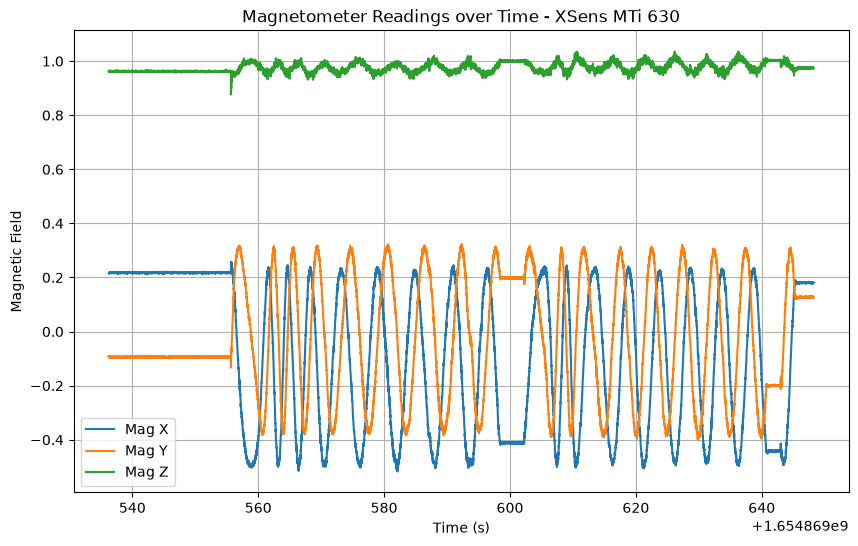

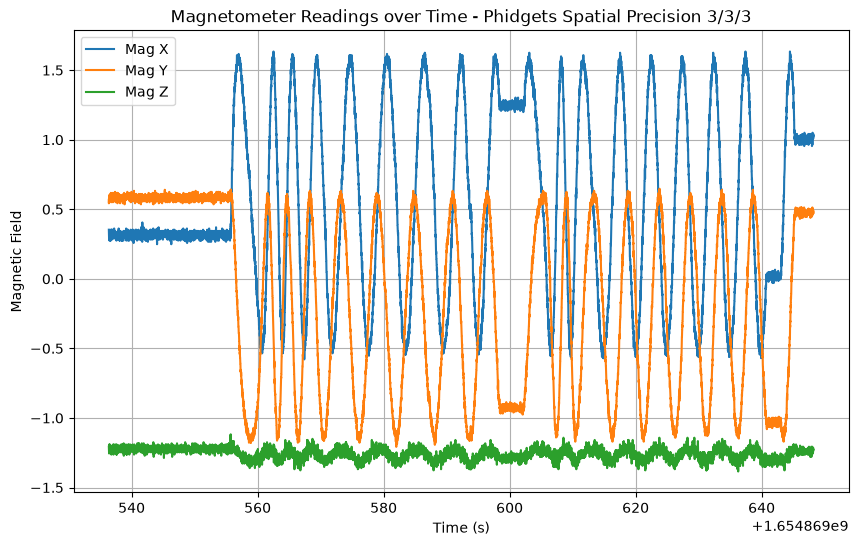

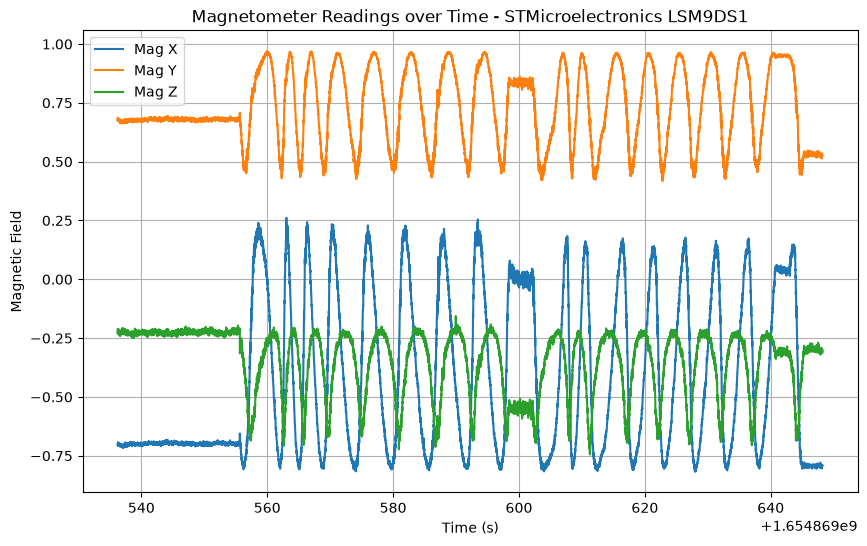

In [2]:
def plot_mag_data(_mag_data, imu_model=None, show=False):

    plot_title = "Magnetometer Readings over Time"
    if imu_model is not None:
        plot_title += " - " + imu_model

    plt.figure(figsize=(10, 6))
    try:        
        plt.plot(_mag_data['Time'], _mag_data['vector.x'], label='Mag X')
        plt.plot(_mag_data['Time'], _mag_data['vector.y'], label='Mag Y')
        plt.plot(_mag_data['Time'], _mag_data['vector.z'], label='Mag Z')
    except KeyError:
        plt.plot(_mag_data['Time'], _mag_data['magnetic_field.x'], label='Mag X')
        plt.plot(_mag_data['Time'], _mag_data['magnetic_field.y'], label='Mag Y')
        plt.plot(_mag_data['Time'], _mag_data['magnetic_field.z'], label='Mag Z')
    plt.xlabel('Time (s)')
    plt.ylabel('Magnetic Field')

    plt.title(plot_title)
    plt.legend()
    plt.grid(True)
    if show:
        plt.show()


# 1. Read the bag file
b = bagreader('./hibachi_log_2022-06-10-10-58-55.bag')

# 2. Get the specific topic's data (saves as a CSV automatically)
# To find your topic names, you can first run: print(b.topic_table)
# print(b.topic_table)

# The magnetometer topics are the following
# /mti_630_8A1G6/imu/mag ---> XSens MTi 630
# /phidgets_373223/imu/mag ---> Phidgets Spatial Precision 3/3/3
# /hibachi_imu_node/mag ---> STMicroelectronics LSM9DS1

mti_630_mag = b.message_by_topic(topic='/mti_630_8A1G6/imu/mag')
phidgets_mag = b.message_by_topic(topic='/phidgets_373223/imu/mag')
lsm9ds1_mag = b.message_by_topic(topic='/hibachi_imu_node/mag')


# 3.1. Load the data into a pandas DataFrame
df0 = pd.read_csv(mti_630_mag)
print(df0.columns)

# 3.2. Plot the data
plot_mag_data(df0, imu_model="XSens MTi 630", show=False)

# 4.1. Load the data into a pandas DataFrame
df1 = pd.read_csv(phidgets_mag)
# Pasar a [G]
df1['magnetic_field.x'] /= 1e-4
df1['magnetic_field.y'] /= 1e-4
df1['magnetic_field.z'] /= 1e-4

# 4.2. Plot the data
plot_mag_data(df1, imu_model="Phidgets Spatial Precision 3/3/3", show=False)

# 5.1. Load the data into a pandas DataFrame
df2 = pd.read_csv(lsm9ds1_mag)
# Pasar a [G]
df2['magnetic_field.x'] /= 1e-4
df2['magnetic_field.y'] /= 1e-4
df2['magnetic_field.z'] /= 1e-4

# 5.2. Plot the data
plot_mag_data(df2, imu_model="STMicroelectronics LSM9DS1", show=True)

In [5]:
print(df0.columns)
print(df1.columns)
print(df2.columns)

Index(['Time', 'header.seq', 'header.stamp.secs', 'header.stamp.nsecs',
       'header.frame_id', 'vector.x', 'vector.y', 'vector.z'],
      dtype='str')
Index(['Time', 'header.seq', 'header.stamp.secs', 'header.stamp.nsecs',
       'header.frame_id', 'magnetic_field.x', 'magnetic_field.y',
       'magnetic_field.z', 'magnetic_field_covariance_0',
       'magnetic_field_covariance_1', 'magnetic_field_covariance_2',
       'magnetic_field_covariance_3', 'magnetic_field_covariance_4',
       'magnetic_field_covariance_5', 'magnetic_field_covariance_6',
       'magnetic_field_covariance_7', 'magnetic_field_covariance_8'],
      dtype='str')
Index(['Time', 'header.seq', 'header.stamp.secs', 'header.stamp.nsecs',
       'header.frame_id', 'magnetic_field.x', 'magnetic_field.y',
       'magnetic_field.z', 'magnetic_field_covariance_0',
       'magnetic_field_covariance_1', 'magnetic_field_covariance_2',
       'magnetic_field_covariance_3', 'magnetic_field_covariance_4',
       'magnetic_fie

In [7]:
for nombre, df in [("Xsens", df0),("Phidgets", df1), ("LSM9DS1", df2)]:
    try:
        Mk = df[['vector.x','vector.y','vector.z']].to_numpy()
    except KeyError:
        Mk = df[['magnetic_field.x','magnetic_field.y','magnetic_field.z']].to_numpy()
    xk, yk, zk = Mk[:,0], Mk[:,1], Mk[:,2]
    print(nombre, "std x,y,z:", xk.std(), yk.std(), zk.std(), " rango z:", zk.max()-zk.min())

Xsens std x,y,z: 0.2735620211605192 0.21658673211143759 0.018015553397013877  rango z: 0.15904831886291504
Phidgets std x,y,z: 0.6666707163815075 0.6597053231995947 0.04043607291814199  rango z: 0.26721000000000017
LSM9DS1 std x,y,z: 0.347134873355247 0.16037984681005796 0.1406677808185774  rango z: 0.588262737437617
